In [43]:
#################### DOCUMENTATION #########################
'''
Author: Spencer Ressel
Date: 2025-10-27

This code runs the NeuralGCM model using ERA5 data as an initial condition. It is designed to run the model in a quasi-linear way, with a mean-state term that does not evolve in time and a small MJO perturbation that evolves relative to the mean-state. 


'''
############################################################

######################### IMPORTS ##########################

print(f"{'Loading imports...':<30}", end="")
import gcsfs
import jax
from jax import config
import jax.numpy as jnp
import copy
import numpy as np
import pickle
import xarray as xr
import json
import os
import pandas as pd
from datetime import datetime
from pathlib import Path

from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils
import neuralgcm
from neuralgcm import PressureLevelModel
from jax_helper_functions import *
from smooth_encoded_state import smooth_encoded_state
# base_directory = Path("/u/sressel/neuralgcm/model_outputs")
print('\u2713')
###############################################################

Loading imports...            ✓


In [2]:
#################### SIMULATION PARAMETERS ####################
experiment_name = 'code_formatting_changes_test_5'
experiment_description = 'This is a 10-day test of the 2.8deg deterministic model with 1-hr timesteps. There is a perturbation and the mean-state is corrected.'
simulation_parameters = dict(
    add_perturbation = True,
    correct_mean_state = True,
    smooth_initial_conditions = False
)
#### Specify the number of timesteps
n_timesteps = int(10*24)
random_key = 37
rng_key = jax.random.key(random_key)  # optional for deterministic models

print(f"{'Specifying model...':<30}", end="")
model_name = 'v1/deterministic_2_8_deg.pkl'  #@param ['v1/deterministic_0_7_deg.pkl', 'v1/deterministic_1_4_deg.pkl', 'v1/deterministic_2_8_deg.pkl', 'v1/stochastic_1_4_deg.pkl', 'v1_precip/stochastic_precip_2_8_deg.pkl', 'v1_precip/stochastic_evap_2_8_deg'] {type: "string"}
# model_name = 'v1_precip/stochastic_precip_2_8_deg.pkl'  #@param ['v1/deterministic_0_7_deg.pkl', 'v1/deterministic_1_4_deg.pkl', 'v1/deterministic_2_8_deg.pkl', 'v1/stochastic_1_4_deg.pkl', 'v1_precip/stochastic_precip_2_8_deg.pkl', 'v1_precip/stochastic_evap_2_8_deg'] {type: "string"}

gcs = gcsfs.GCSFileSystem(token='anon')
with gcs.open(f'gs://neuralgcm/models/{model_name}', 'rb') as f:
  ckpt = pickle.load(f)

model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)
print('\u2713')
###############################################################

Specifying model...           ✓


In [3]:
################### LOAD INITIAL CONDITIONS ###################
print(f"{'Loading initial conditions...':<30}", end="")

import pandas as pd
eval_era5 = xr.load_dataset(
    f"./2_8_thirty_year_DJF_climatology.nc"
).drop_vars('time_bnds').isel(time=0, drop=True).expand_dims(time=[pd.Timestamp('2000-01-15')])

# eval_era5 = eval_era5.load()
u_wind = eval_era5['u_component_of_wind'].copy()
mean_u_wind = u_wind.mean()
eval_era5['u_component_of_wind'] = eval_era5['u_component_of_wind'].mean().broadcast_like(eval_era5['u_component_of_wind'])
eval_era5['v_component_of_wind'] = eval_era5['v_component_of_wind'].mean().broadcast_like(eval_era5['v_component_of_wind'])
# eval_era5['geopotential'] = eval_era5['geopotential'].mean().broadcast_like(eval_era5['geopotential'])
# eval_era5['specific_humidity'] = eval_era5['specific_humidity'].mean().broadcast_like(eval_era5['specific_humidity'])


# demo_start_time = '2000-01-15'
# eval_era5 = xr.load_dataset(
#     f"../neuralgcm/neuralgcm/input/2_8_thirty_year_DJF_climatology.nc"
# ).isel(time=0, drop=True).expand_dims(time=[pd.Timestamp('2000-01-15')])
print('\u2713')

#### Add a perturbation
# mjo_composites = xr.load_dataset(
#     f"../neuralgcm/neuralgcm/input/MJO_phase_composites.nc"
# )
mjo_composites = xr.load_dataset("/glade/campaign/univ/uwas0152/neuralGCM_data/MJO_phase_composites.nc")

print(f"{'Configuring model...':<30}", end="")
# initialize model state (bring ERA5 snapshot --> encoding into the model's latent state)
inputs_dict = model.inputs_from_xarray(eval_era5.isel(time=0))
perturbed_inputs_dict = model.inputs_from_xarray((eval_era5 + mjo_composites.sel(phase=5, drop=True)).isel(time=0))
input_forcings = model.forcings_from_xarray(eval_era5.isel(time=0))

# Encode initial data into model state
mean_state = model.encode(inputs_dict, input_forcings, rng_key)
perturbed_initial_state = model.encode(perturbed_inputs_dict, input_forcings, rng_key)

# Create an initial condition based on whether a perturbation is included
if simulation_parameters['add_perturbation']:
    initial_state = copy.deepcopy(perturbed_initial_state)
else:
    initial_state = copy.deepcopy(mean_state)
print('\u2713')
#################################################################

Loading initial conditions... ✓
Configuring model...          ✓


In [4]:
################## CALCULATE MEAN-STATE CORRECTION ##############
print(f"{'Calculating mean-state correction...':<30}", end="")
config.update("jax_enable_x64", False)
evolved_mean_state = model.advance(mean_state, input_forcings)

mean_state_correction = copy.deepcopy(mean_state)
config.update("jax_enable_x64", True)
mean_state_correction.state = tree_subtraction(
        tree_to_float64(evolved_mean_state.state),
        tree_to_float64(mean_state.state)
)
config.update("jax_enable_x64", False)
mean_state_correction_float32 = mean_state_correction.replace(state = tree_to_float32(mean_state_correction.state))
# decoded_mean_state_correction = model.data_to_xarray(model.decode(mean_state_correction_float32, input_forcings), times=None)
print('\u2713')
#################################################################

Calculating mean-state correction...✓


In [53]:
######################### TIMESTEPPING ##########################
print(f"{'Running model...':<30}", end="")
predictions_list = []
predictions_list.append(model.data_to_xarray(model.decode(initial_state, input_forcings), times=None))
model_states_list = []

model_states_list.append(initial_state)
for timestep in np.arange(0, 5, 1):

    # Advance the model state forward by one timestep
    if timestep == 0:
        config.update("jax_enable_x64", False)
        advanced_state = model.advance(initial_state, input_forcings)

    else:
        config.update("jax_enable_x64", False)
        advanced_state = model.advance(corrected_advanced_state, input_forcings)

    if simulation_parameters['correct_mean_state']:
        # Apply the mean-state correction
        corrected_advanced_state = copy.deepcopy(initial_state)
        config.update("jax_enable_x64", True)
        corrected_advanced_state.state = tree_to_float32(
            tree_subtraction(
                tree_to_float64(advanced_state.state),
                mean_state_correction.state
            )
        )
        config.update("jax_enable_x64", False)
    else:
        # Advance the uncorrected state
        corrected_advanced_state = copy.deepcopy(advanced_state)

    corrected_advanced_state = smooth_encoded_state(corrected_advanced_state, 42)

    # Save the advanced states to an xr DataArray
    predictions_list.append(model.data_to_xarray(model.decode(corrected_advanced_state, input_forcings), times=None))
    model_states_list.append(corrected_advanced_state)

# Concatenate the states into a single DataArray
concatenated_predictions_ds = xr.concat(
    xr.align(*[prediction for prediction in predictions_list]),
    dim='time'
)
print('\u2713')
#################################################################

Running model...              ✓


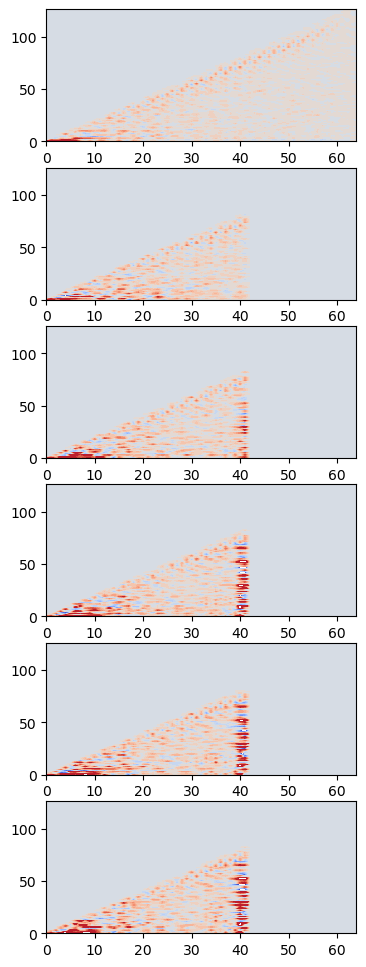

In [54]:
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
[fig, ax] = plt.subplots(len(model_states_list), 1, figsize=(4,12))
[
    ax[index].contourf(
        (
            model_states_list[index].state.divergence[0]
            # - model_states_list[0].state.divergence[0]
        ),
        levels=np.linspace(-0.001, 0.001, 21),
        cmap='coolwarm',
        norm=mcolors.CenteredNorm(vcenter=0)
    )
    for index in range(len(model_states_list))
]

In [23]:
model_states_list[0].state.divergence[0].min()

Array(-0.00195323, dtype=float32)

In [28]:
# config.update("jax_enable_x64", True)
# difference = tree_subtraction(
#         tree_to_float64(advanced_state.state),
#         mean_state_correction.state
#     )
# config.update("jax_enable_x64", False)
# difference.state.vorticity

from dinosaur import spherical_harmonic

# nodal_vorticity = model.model_coords.horizontal.to_nodal(corrected_advanced_state.state.vorticity)
# nodal_divergence = model.model_coords.horizontal.to_nodal(corrected_advanced_state.state.divergence)

# nodal_u_wind, nodal_v_wind = spherical_harmonic.vor_div_to_uv_nodal(
#     model.model_coords.horizontal,
#     corrected_advanced_state.state.vorticity,
#     corrected_advanced_state.state.divergence,
# )

# encoded_ds = model.data_to_xarray(
#     {
#         'vorticity': model.from_nondim_units(nodal_vorticity, '1/s'),
#         'divergence': model.from_nondim_units(nodal_divergence, '1/s'),
#         'u_wind': model.from_nondim_units(nodal_u_wind, 'm/s'),
#         'v_wind': model.from_nondim_units(nodal_v_wind, 'm/s'),
#     },
#     times=None,
#     decoded=False,
# )

nodal_vorticity = model.model_coords.horizontal.to_nodal(initial_state.state.vorticity)
nodal_divergence = model.model_coords.horizontal.to_nodal(initial_state.state.divergence)

nodal_u_wind, nodal_v_wind = spherical_harmonic.vor_div_to_uv_nodal(
    model.model_coords.horizontal,
    initial_state.state.vorticity,
    initial_state.state.divergence,
)

initial_ds = model.data_to_xarray(
    {
        'vorticity': model.from_nondim_units(nodal_vorticity, '1/s'),
        'divergence': model.from_nondim_units(nodal_divergence, '1/s'),
        'u_wind': model.from_nondim_units(nodal_u_wind, 'm/s'),
        'v_wind': model.from_nondim_units(nodal_v_wind, 'm/s'),
    },
    times=None,
    decoded=False,
)

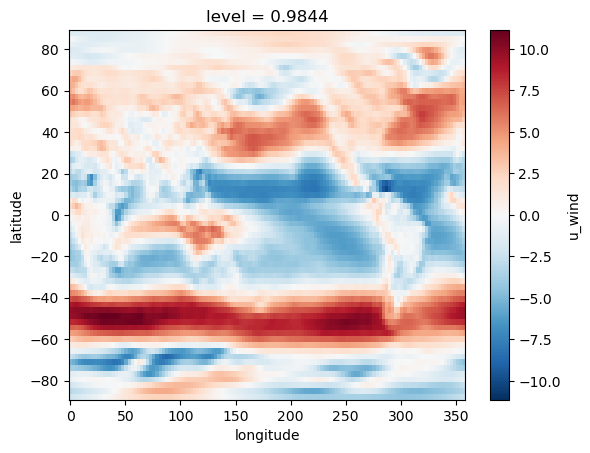

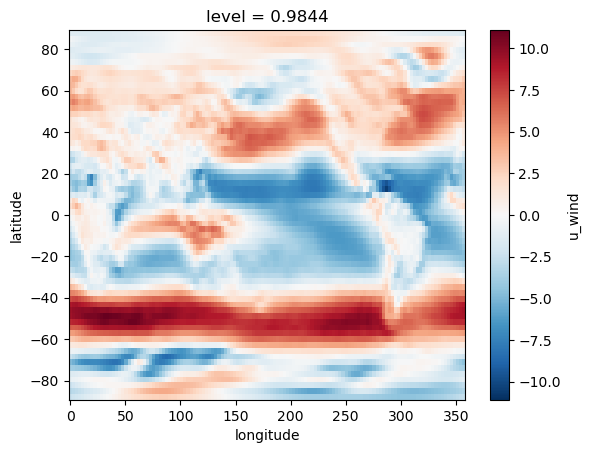

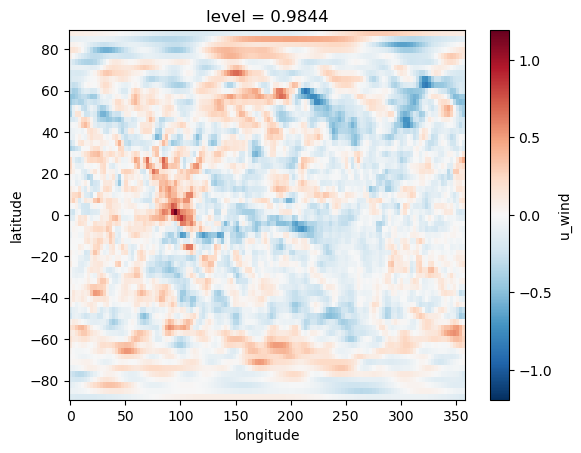

In [33]:
encoded_ds['u_wind'].isel(level=-1).plot(x='longitude')
plt.figure()
initial_ds['u_wind'].isel(level=-1).plot(x='longitude')
plt.figure()
(initial_ds['u_wind'].isel(level=-1) - encoded_ds['u_wind'].isel(level=-1)).plot(x='longitude')

In [ ]:


############################## OUTPUT ###########################
print(f"{'Saving output...':<30}", end="")
# Log model/experiment parameters
experiment_parameters = {
    'experiment_name': experiment_name,
    'description': experiment_description,
    'model_name': model_name,
    'demo_start_time': demo_start_time,
    'n_timesteps': n_timesteps,
    'random_key': random_key,
    'simulation_parameters': simulation_parameters,
}

# Create a unique identifier for each experimental run
file_timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# Save each experiments data to a new folder
output_folder_name = f"{experiment_parameters['experiment_name']}_{file_timestamp}"
output_folder = base_directory / output_folder_name
output_folder.mkdir(parents=True, exist_ok=False)

# Save the experiment parameters
json_path = output_folder / "experiment_parameters.json"
with open(json_path, "w") as f:
    json.dump(experiment_parameters, f, indent=4)

# Save the experiment data
concatenated_predictions_ds.to_netcdf(output_folder / "model_output.nc")
decoded_mean_state_correction.to_netcdf(output_folder / "mean_state_correction.nc")

# Create running experiment log
experiments_log_file = base_directory / "experiment_log.json"
if experiments_log_file.exists():
    with open(experiments_log_file, "r") as f:
        log_data = json.load(f)

else:
    log_data = []

log_data.insert(
    0,
    {
        'experiment_name': experiment_parameters['experiment_name'],
        'timestamp': file_timestamp,
        'description': experiment_parameters['description']
    }
)

# Save updated log
with open(experiments_log_file, "w") as f:
    json.dump(log_data, f, indent=4)

# Path to the running script
script_path = os.path.abspath(__file__)

# Read the source code
with open(script_path, 'r') as f:
    script_contents = f.read()

filename = f"multi_day_mean_state_test_{file_timestamp}.py"

# Save in the experiment folder
save_path = os.path.join(output_folder, filename)
with open(save_path, 'w') as f:
    f.write(script_contents)
print('\u2713')
####################################################################

print("Finished")